STEP 1 - Import Required Libraries and Dependencies: Load Python libraries needed for data manipulation, visualization, dimensionality reduction, clustering, and model evaluation.

In [1]:
# Step #1: Import Required Libraries and Dependencies

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


STEP 2 -  Load and Initialize the Wine Dataset: Import the wine dataset into Python and verify that the data has been successfully loaded for analysis.

In [2]:
# Step #2: Load and Initialize the Wine Dataset

df = pd.read_csv("wine-clustering.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


STEP 3 -  Perform Exploratory Data Analysis (EDA):Examine dataset structure, data types, missing values, duplicate records, and descriptive statistics to assess data quality.

In [3]:
# Step #3: Perform Exploratory Data Analysis (EDA)

df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB

Missing Values:
Alcohol                 0
Malic_Acid              0
Ash      

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic_Acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Ash_Alcanity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_Phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_Intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


STEP 4 -  Examine Correlations

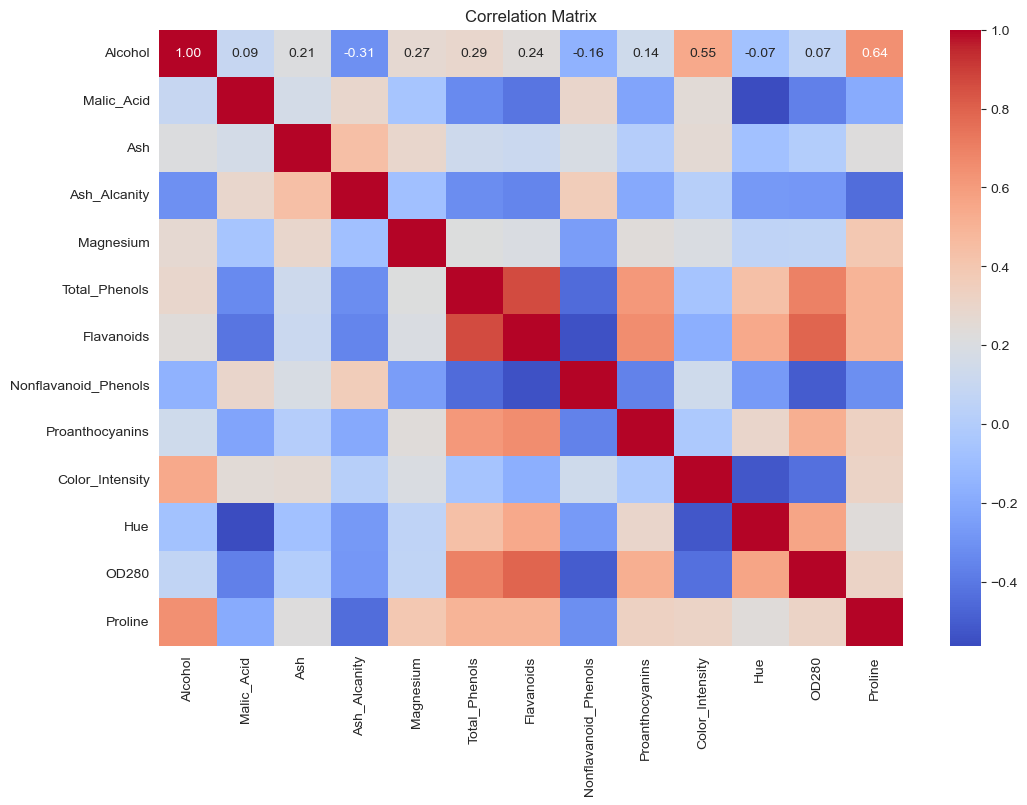

In [4]:
# Step #4: Correlation Analysis

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.savefig("Wine_Clustering_PCA_KMeans_Hierarchical/reports/figures/correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

STEP 5 -  Investigate PCA Assumptions and Feature Distributions: Examine variable distributions, potential outliers, and overall data characteristics before applying PCA.

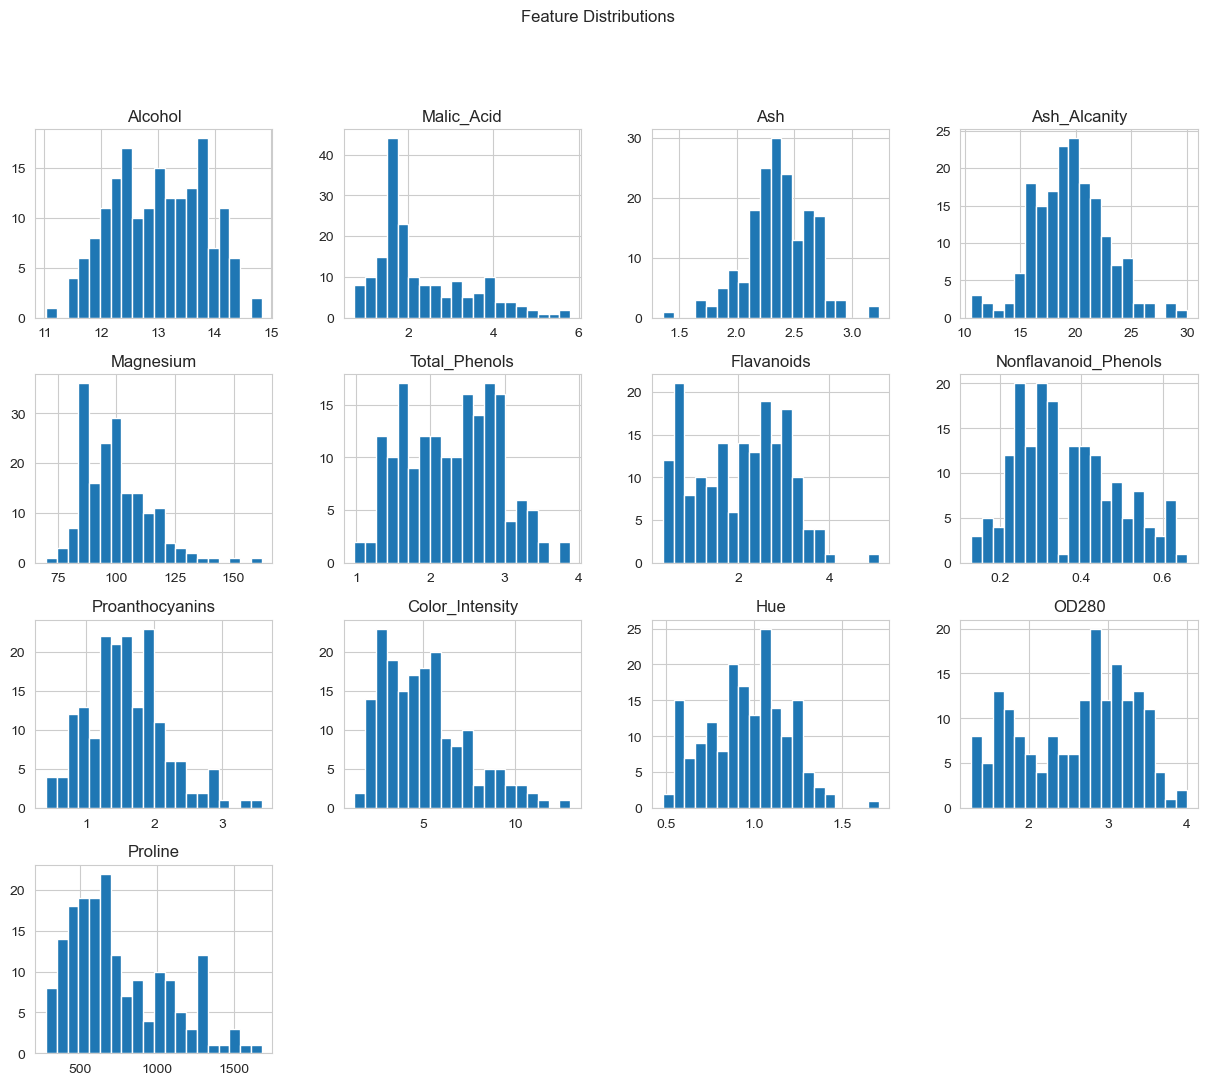

In [5]:
# Step #5: Investigate PCA Assumptions and Feature Distributions

df.hist(
    figsize=(15,12),
    bins=20
)

plt.suptitle("Feature Distributions")

plt.savefig("Wine_Clustering_PCA_KMeans_Hierarchical/reports/figures/feature_distributions.png", dpi=300, bbox_inches="tight")

plt.show()

STEP 6 -  Standardize Feature Variables: Scale all predictors to a common measurement scale so no variable dominates the PCA or clustering process.

In [6]:
# Step #6: Standardize Feature Variables

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print("Standardization complete.")

Standardization complete.


STEP 7 -  Conduct Initial Principal Component Analysis (PCA): Calculate principal components and determine how much variance each component explains.

In [7]:
# Step #7: Conduct Initial Principal Component Analysis (PCA)

pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

print(explained_variance)

[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


STEP 8 -  Generate PCA Scree Plot: Visualize cumulative explained variance to identify the optimal number of principal components to retain.

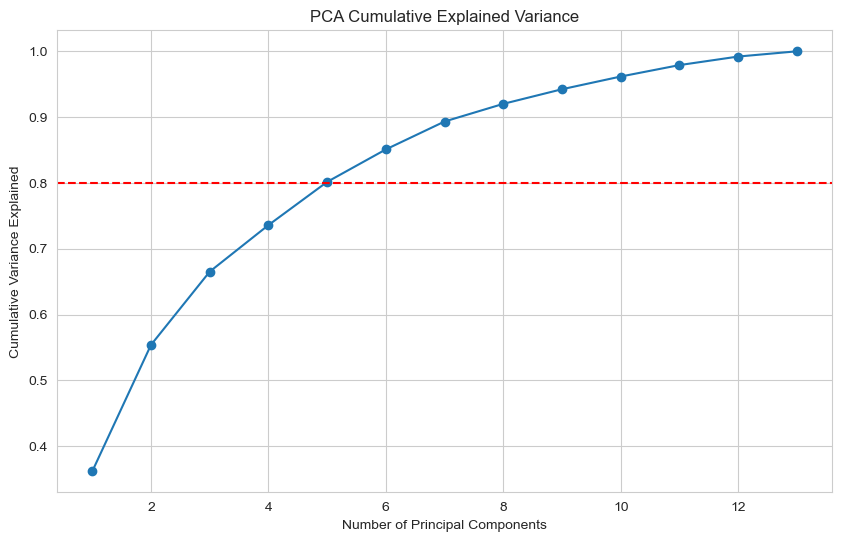

In [8]:
# Step #8: Generate PCA Scree Plot

plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(explained_variance)+1),
    np.cumsum(explained_variance),
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Cumulative Explained Variance")
plt.axhline(y=0.80, color='red', linestyle='--')

plt.savefig("Wine_Clustering_PCA_KMeans_Hierarchical/reports/figures/pca_cumulative_explained_variance.png", dpi=300, bbox_inches="tight")

plt.show()

STEP 9 -  Select Components Retaining 80% Variance: Determine the minimum number of components required to preserve at least 80% of the dataset's information.

In [9]:
# Step #9: Select Components Retaining 80% Variance

cumulative_variance = np.cumsum(explained_variance)

n_components = np.argmax(cumulative_variance >= 0.80) + 1

print("Number of Components for 80% Variance:", n_components)

Number of Components for 80% Variance: 5


STEP 10 -  Apply PCA Dimensionality Reduction: Reduce the original dataset into a smaller set of principal components while preserving most variation.

In [10]:
# Step #10: Apply PCA Dimensionality Reduction

pca = PCA(n_components=n_components)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (178, 13)
Reduced Shape: (178, 5)


STEP 11 -  Interpret Principal Component Loadings: Identify which original variables contribute most strongly to each retained principal component.

In [11]:
# Step #11: Interpret Principal Component Loadings

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(n_components)],
    index=df.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5
Alcohol,0.144329,-0.483652,-0.207383,-0.017856,-0.265664
Malic_Acid,-0.245188,-0.224931,0.089013,0.536890,0.035214
Ash,-0.002051,-0.316069,0.626224,-0.214176,-0.143025
Ash_Alcanity,-0.239320,0.010591,0.612080,0.060859,0.066103
Magnesium,0.141992,-0.299634,0.130757,-0.351797,0.727049
Total_Phenols,0.394661,-0.065040,0.146179,0.198068,-0.149318
Flavanoids,0.422934,0.003360,0.150682,0.152295,-0.109026
Nonflavanoid_Phenols,-0.298533,-0.028779,0.170368,-0.203301,-0.500703
Proanthocyanins,0.313429,-0.039302,0.149454,0.399057,0.136860
Color_Intensity,-0.088617,-0.529996,-0.137306,0.065926,-0.076437


STEP 12 -  Visualize PCA Component Structure: Plot observations within principal component space to identify potential clustering patterns.

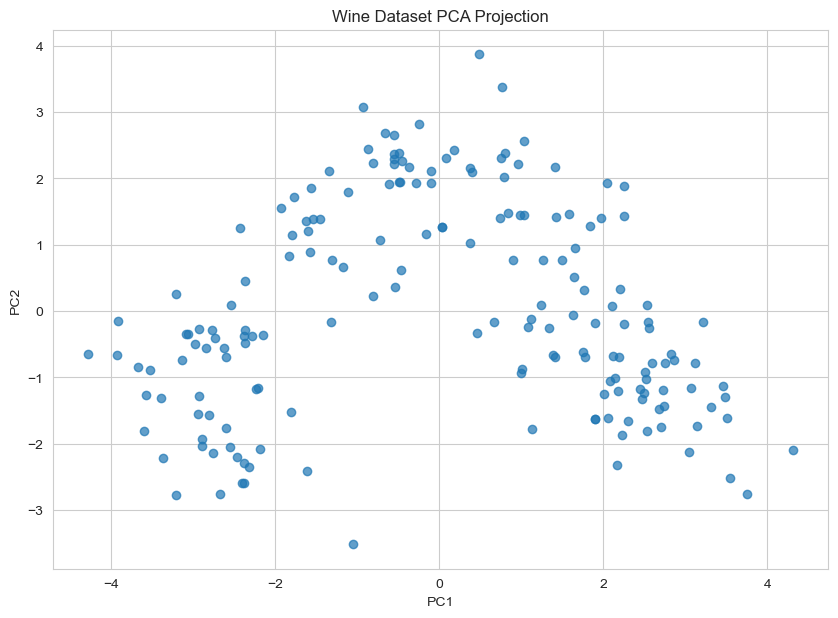

In [12]:
# Step #12: Visualize PCA Component Structure

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Dataset PCA Projection")

plt.savefig("Wine_Clustering_PCA_KMeans_Hierarchical/reports/figures/wine_dataset-PCA_projection.png", dpi=300, bbox_inches="tight")

plt.show()

STEP 13 -  Determine Optimal K Using the Elbow Method: Compare within-cluster variation across multiple values of k to identify a suitable cluster count.

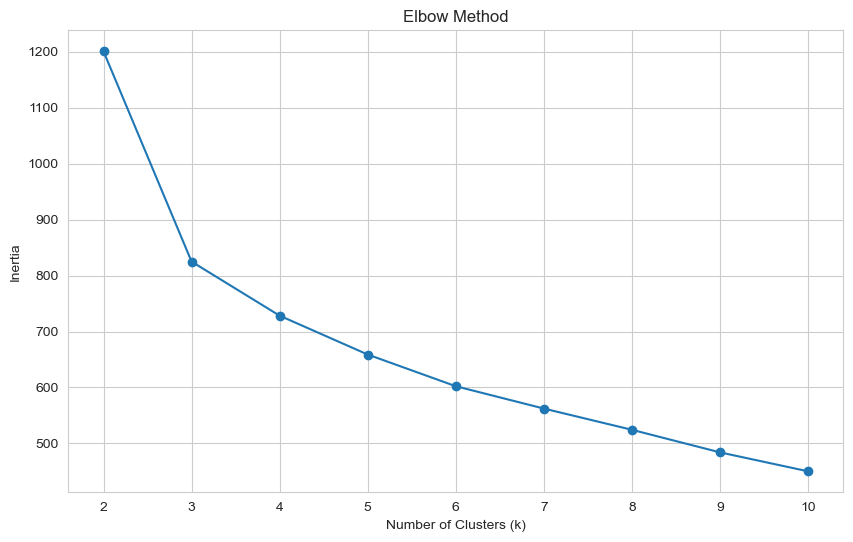

In [13]:
# Step #13: Determine Optimal K Using the Elbow Method

inertia = []

k_values = range(2,11)

for k in k_values:
    
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    km.fit(X_pca)
    
    inertia.append(km.inertia_)

plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.savefig("Wine_Clustering_PCA_KMeans_Hierarchical/reports/figures/elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()

STEP 14 -  Evaluate Cluster Quality with Silhouette Analysis: Measure cluster cohesion and separation to determine the strongest clustering solution.

In [14]:
# Step #14: Evaluate Cluster Quality with Silhouette Analysis

scores = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    scores.append(score)

silhouette_df = pd.DataFrame({
    "K": range(2,11),
    "Silhouette Score": scores
})

silhouette_df

,K,Silhouette Score
0,2,0.323917
1,3,0.369076
2,4,0.328523
3,5,0.311320
4,6,0.321839
5,7,0.277957
6,8,0.225916
7,9,0.210782
8,10,0.221916


STEP 15 -  Visualize Silhouette Performance Across K Values: Compare silhouette scores for different cluster numbers and validate the optimal k selection.

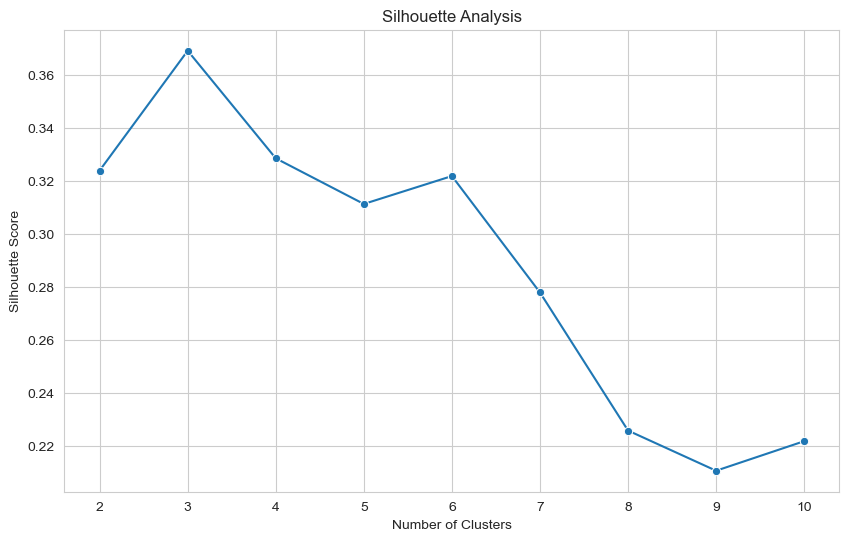

In [15]:
# Step #15: Visualize Silhouette Performance Across K Values

plt.figure(figsize=(10,6))

sns.lineplot(
    x=range(2,11),
    y=scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.savefig("Wine_Clustering_PCA_KMeans_Hierarchical/reports/figures/silhouette_analysis.png", dpi=300, bbox_inches="tight")

plt.show()

STEP 16 -  Train the Optimal K-Means Clustering Model: Build the final K-Means model using the best-performing value of k identified previously.

In [16]:
# Step #16: Train the Optimal K-Means Clustering Model

best_k = silhouette_df.loc[
    silhouette_df["Silhouette Score"].idxmax(),
    "K"
]

print("Best K:", best_k)

kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

df["Cluster"] = clusters

Best K: 3


STEP 17 -  Visualize K-Means Cluster Separation: Display cluster assignments in PCA space and evaluate the distinctness of cluster boundaries.

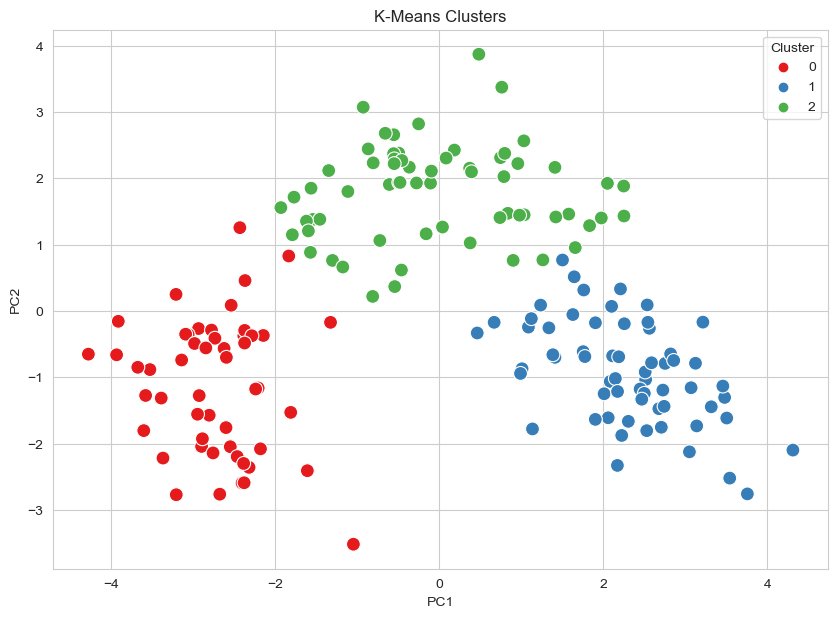

In [17]:
# Step #17: Visualize K-Means Cluster Separation

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca_2d[:,0],
    y=X_pca_2d[:,1],
    hue=df["Cluster"],
    palette="Set1",
    s=100
)

plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig("Wine_Clustering_PCA_KMeans_Hierarchical/reports/figures/K-Means_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

STEP 18 -  Analyze Cluster Membership Distribution:  Determine the number of observations assigned to each cluster and assess cluster balance. 

In [18]:
# Step #18: Analyze Cluster Membership Distribution

cluster_counts = df["Cluster"].value_counts()

print(cluster_counts)

Cluster
2    65
1    62
0    51
Name: count, dtype: int64


STEP 19 -  Develop Cluster Profile Summaries: Calculate average feature values for each cluster to understand cluster characteristics.

In [19]:
# Step #19: Develop Cluster Profile Summaries

cluster_profiles = df.groupby("Cluster").mean()

cluster_profiles

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Cluster,,,,,,,,,,,,,
0,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
1,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806
2,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231


STEP 20 -  Visualize Cluster Characteristics Using Heatmaps:Compare feature patterns across clusters and identify distinguishing attributes.

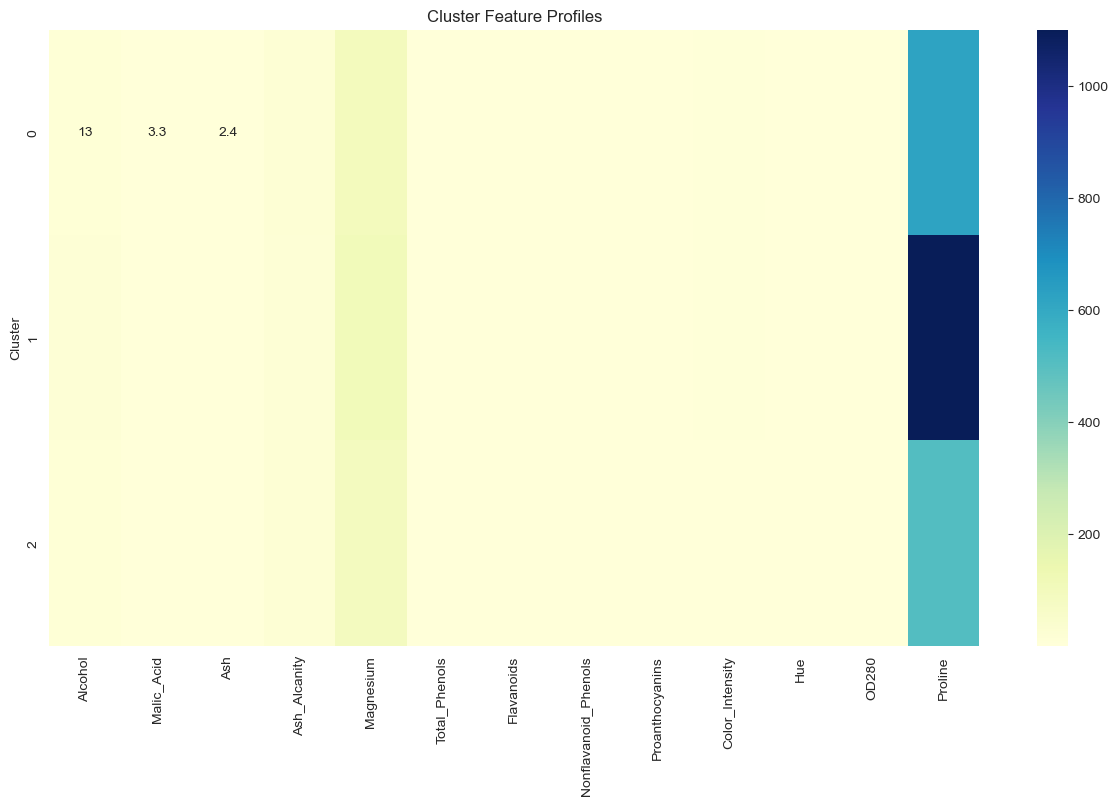

In [20]:
# Step #20: Visualize Cluster Characteristics Using Heatmaps

plt.figure(figsize=(15,8))

sns.heatmap(
    cluster_profiles,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Cluster Feature Profiles")

plt.savefig("Wine_Clustering_PCA_KMeans_Hierarchical/reports/figures/cluster_feature_profiles.png", dpi=300, bbox_inches="tight")

plt.show()

STEP 21 -  Perform Hierarchical Clustering Analysis: Apply complete-linkage hierarchical clustering to evaluate alternative cluster structures.

In [21]:
# Step #21: Perform Hierarchical Clustering Analysis

linkage_matrix = linkage(
    X_pca,
    method='complete',
    metric='euclidean'
)

print("Hierarchical clustering complete.")

Hierarchical clustering complete.


STEP 22 -  Construct and Interpret the Dendrogram: Visualize hierarchical relationships and identify meaningful cluster formations.

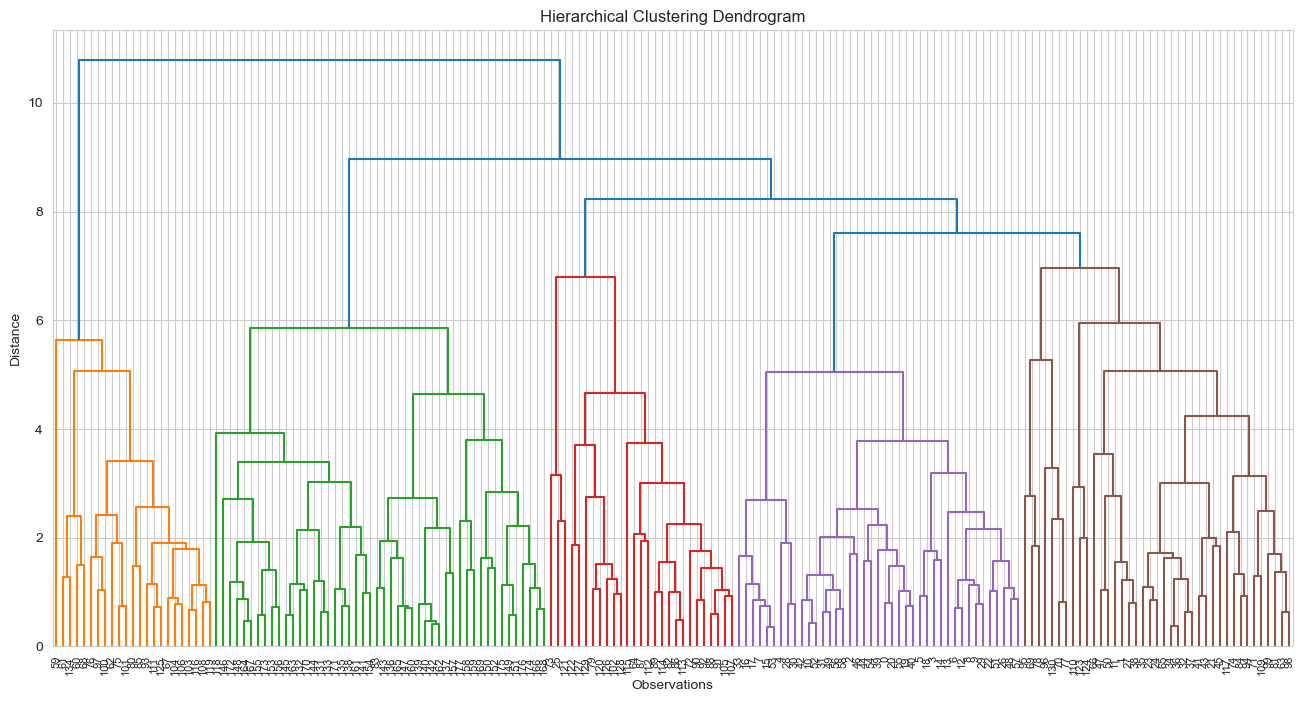

In [22]:
# Step #22: Construct and Interpret the Dendrogram

plt.figure(figsize=(16,8))

dendrogram(
    linkage_matrix,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")

plt.savefig("Wine_Clustering_PCA_KMeans_Hierarchical/reports/figures/hierarchical_clustering_dendrogram.png", dpi=300, bbox_inches="tight")

plt.show()

STEP 23 -  Generate Hierarchical Cluster Assignments: Create cluster memberships based on the selected hierarchical clustering solution.

In [23]:
# Step #23: Generate Hierarchical Cluster Assignments

hier_clusters = fcluster(
    linkage_matrix,
    t=3,
    criterion='maxclust'
)

df["Hierarchical_Cluster"] = hier_clusters

print(df["Hierarchical_Cluster"].value_counts())

Hierarchical_Cluster
3    107
2     48
1     23
Name: count, dtype: int64


STEP 24 -  Assess Dendrogram Reliability with Cophenetic Correlation: Evaluate how accurately the dendrogram represents distances among observations.

In [24]:
# Step #24: Assess Dendrogram Reliability with Cophenetic Correlation

coph_corr, coph_dist = cophenet(
    linkage_matrix,
    pdist(X_pca)
)

print("Cophenetic Correlation:", round(coph_corr,4))

Cophenetic Correlation: 0.5433


STEP 25 -  Compare K-Means and Hierarchical Clustering Results: Examine agreement and differences between the two clustering approaches.

In [25]:


comparison = pd.crosstab(
    df["Cluster"],
    df["Hierarchical_Cluster"]
)

comparison

Hierarchical_Cluster,1,2,3
Cluster,,,
0,2,48,1
1,0,0,62
2,21,0,44


STEP 26 -  Summarize Key Findings and Model Performance: Consolidate major results, including retained PCA components, explained variance, optimal clusters, and clustering quality metrics.

In [26]:
# Step #26: Summarize Key Findings and Model Performance